In [ ]:
import serial
import time
import csv
import matplotlib.pyplot as plt    
import pandas as pd
# -----------------------------
# USER SETTINGS
# -----------------------------
PORT = "COM4"          # change if needed
BAUD = 115200
DURATION = 50          # seconds to record
CSV_FILE = "data/Athul/.csv"

# -----------------------------
# SERIAL SETUP
# -----------------------------
ser = serial.Serial(PORT, BAUD, timeout=1)
time.sleep(2)  # allow ESP32 reset

print("Recording EMG data...")

# -----------------------------
# CSV SETUP
# -----------------------------
with open(CSV_FILE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Time_s", "Raw_EMG", "Envelope_EMG"])

    start_time = time.time()

    while time.time() - start_time < DURATION:
        line = ser.readline().decode(errors="ignore").strip()

        # Expect: raw,envelope
        if "," not in line:
            continue

        try:
            raw, env = map(float, line.split(","))
        except ValueError:
            continue

        timestamp = time.time() - start_time
        writer.writerow([round(timestamp, 4), raw, env])

ser.close()

print(f"✔ Data saved to {CSV_FILE}")


Recording EMG data...
✔ Data saved to data/Athul/R50.csv


In [3]:

df=pd.read_csv("data/Athul/R50.csv")


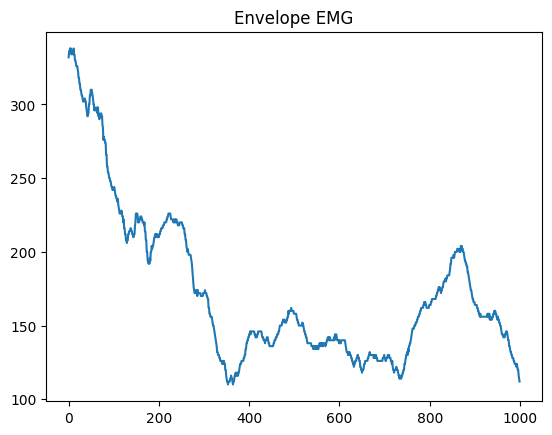

In [5]:

plt.plot(df["Envelope_EMG"][:1000])
plt.title("Envelope EMG")
plt.show()